<a href="https://colab.research.google.com/github/mbrow210/MAT-422/blob/main/1_4_SVD_Low_Rank_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.4: SVD, Low-Rank Approximation, and PCA

**Topics:** singular value decomposition, low-rank matrix approximations, principal component analysis

In [22]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.image as mpimg

import numpy as np
from scipy.linalg import svd
from skimage.color import rgb2gray


np.set_printoptions(precision=4, suppress=True)

## 1.4.1 Singular Value Decomposition (SVD)

*Singular value decomposition factors a matrix A into A = U Sigma V^T. The columns of U and V are orthonormal directions, and the singular values in Sigma measure how much each direction contributes to the matrix.*



---


### Explanation

Singular value decomposition (SVD) is when a matrix $M$ is decomposed into three matrices:

$$M= U Σ V^*$$

> $U$
> - An $m \times m$ unitary matrix.
> - Orthogonal
> - Columns are the **left singular vectors of $M$**
> - Purpose: Shows the factors.

> $Σ$
> - An $m \times n$ diagonal matrix.
> - Diagonal
> - Contains the singular values of $M$ in descending order.
> - Purpose: show the importance of each factor.

> $V^*$
> - The conjugate transpose of $V$ ($n \times n$ unitary/orthogonal matrix)
> - Columns are the right singular vectors of $M$.
> - Purpose: Show how similar the factors are.

### Performing SVD by hand
1. Compute $MM^T$
2. Compute the Eigen**values** of $MM^T$
> - Done by solving the characterisic equation: $det(MM^T - \lambda I)=0$
3. Find the right singular vectors (Eigen**vectors* of $M^TM$ for each eigenvalue $\lambda$)
4. Find the left singular vectors ($U$)
> - Using equation $u_i = \frac{1}{\sigma_i}Mv_i$
5. Use the SVD equation


In [3]:
A = np.array([
    [3, 2, 2],
    [2, 3, -2],
    [1, 1, 0],
    [0, 2, 1],
], dtype=float)

U, s, Vt = np.linalg.svd(A, full_matrices=False)
Sigma = np.diag(s)
A_reconstructed = U @ Sigma @ Vt

print("A =")
print(A)
print("\nSingular values =", s)
print("\nU shape, Sigma shape, Vt shape =", U.shape, Sigma.shape, Vt.shape)
print("\nU.T @ U =")
print(U.T @ U)
print("\nVt @ Vt.T =")
print(Vt @ Vt.T)
print("\nReconstruction error ||A - U Sigma Vt||_F =", np.linalg.norm(A - A_reconstructed, ord="fro"))
print("Reconstruction is accurate?", np.allclose(A, A_reconstructed))

A =
[[ 3.  2.  2.]
 [ 2.  3. -2.]
 [ 1.  1.  0.]
 [ 0.  2.  1.]]

Singular values = [5.4071 3.0452 1.5779]

U shape, Sigma shape, Vt shape = (4, 3) (3, 3) (3, 3)

U.T @ U =
[[ 1.  0. -0.]
 [ 0.  1. -0.]
 [-0. -0.  1.]]

Vt @ Vt.T =
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]

Reconstruction error ||A - U Sigma Vt||_F = 5.375046761694035e-15
Reconstruction is accurate? True


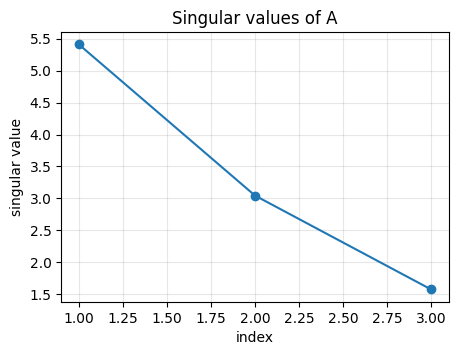

In [4]:
plt.figure(figsize=(5, 3.5))
plt.plot(np.arange(1, len(s) + 1), s, marker="o")
plt.xlabel("index")
plt.ylabel("singular value")
plt.title("Singular values of A")
plt.grid(True, alpha=0.3)
plt.show()

Large singular values indicate directions that carry more structure. Smaller singular values contribute less, which is why SVD is useful for approximation and compression.

## 1.4.2 Low-Rank Matrix Approximations (LRA)

*A rank-k approximation keeps only the first k singular values and singular vectors. This gives a simpler matrix A_k that captures the strongest patterns in A.*



---


### Explanation

LRA is when a matrix that is simpler (lower rannk)than the original matrix by preserving the bigger values and removing the smaller ones to minimixe the size of the original matrix. This process is sed to reduce data size in storage.

It is commonly used in machine learning to derive a meaningful approximation of a large matrix.  

TLDR: LRA is used to minimize matrices by measuring the fit between a large matrix and an approximation matrix.

In [13]:
def rank_k_approximation(U, s, Vt, k):
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

errors = []
for k in range(1, len(s) + 1):
    A_k = rank_k_approximation(U, s, Vt, k)
    error = np.linalg.norm(A - A_k, ord="fro")
    errors.append(error)
    print(f"Rank-{k} approximation:")
    print(A_k)
    print("Frobenius error =", error)
    print("matrix rank =", np.linalg.matrix_rank(A_k))
    print()

Rank-1 approximation:
[[2.3471 2.7154 0.232 ]
 [2.2456 2.5979 0.2219]
 [0.9185 1.0627 0.0908]
 [1.0274 1.1886 0.1015]]
Frobenius error = 3.4297069364073947
matrix rank = 1

Rank-2 approximation:
[[ 2.6053  2.3309  2.1213]
 [ 1.9444  3.0466 -1.9829]
 [ 0.9099  1.0755  0.0277]
 [ 1.1039  1.0748  0.6609]]
Frobenius error = 1.577861346829626
matrix rank = 2

Rank-3 approximation:
[[ 3.  2.  2.]
 [ 2.  3. -2.]
 [ 1.  1.  0.]
 [ 0.  2.  1.]]
Frobenius error = 5.375046761694035e-15
matrix rank = 3



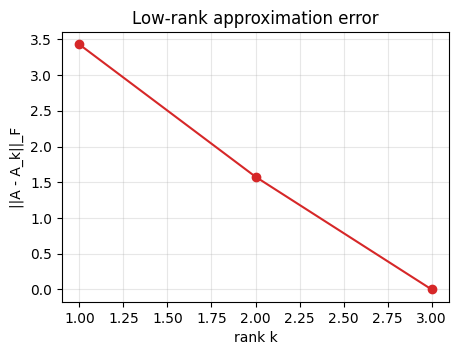

In [14]:
plt.figure(figsize=(5, 3.5))
plt.plot(np.arange(1, len(errors) + 1), errors, marker="o", color="tab:red")
plt.xlabel("rank k")
plt.ylabel("||A - A_k||_F")
plt.title("Low-rank approximation error")
plt.grid(True, alpha=0.3)
plt.show()

The approximation error decreases as k increases. When k reaches the full rank, the approximation becomes the original matrix up to numerical roundoff.

### Use case - Combine SVD and LRA for Image Processing

One of the most common use cases, and one of the easiest to visualize, for LRA, is image processing. This is when an image's quality (pixels) are reduced to shrink the image's file size without losing too much info in the picture. This can be understood visually when looking at a smaller, pixelated version of an image next to the original, uncompressed, image.

By reducing the k value, the number of singular vectors and corresponding values are reduced, which is what causes the decrease in size and quality. The example below demonstrates where the k value can be too low, to the point that the viewers no longer able to discern what the image is supposed to be.

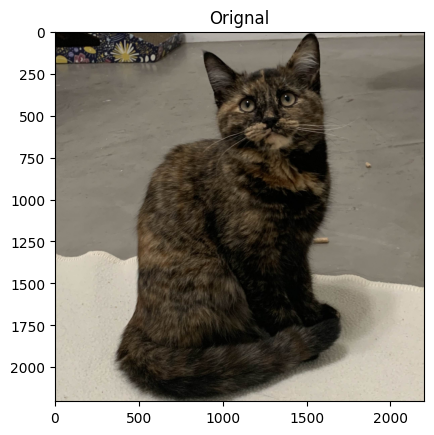

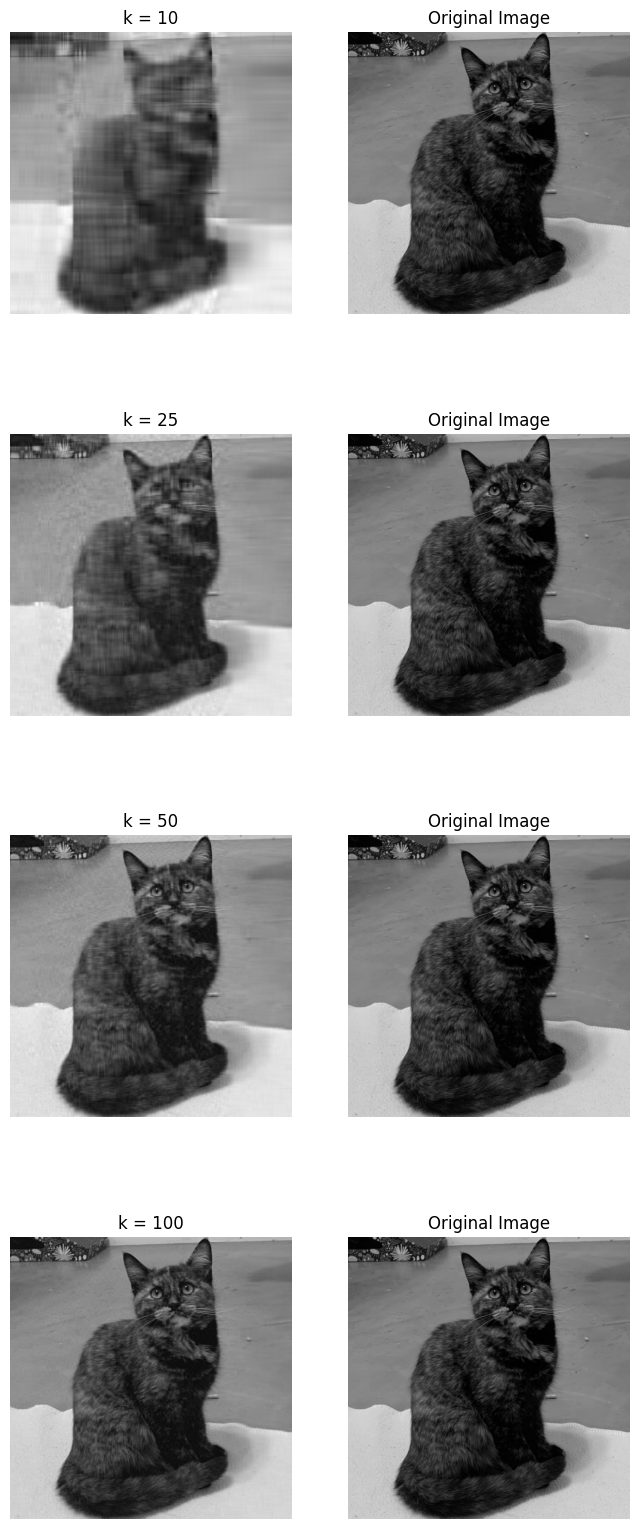

In [36]:
cat = mpimg.imread('/cat.jpg')
plt.imshow(cat)
plt.title("Orignal")
plt.show()

gray_cat = rgb2gray(cat)

fig, ax = plt.subplots(4, 2, figsize=(8, 20))

U, s, Vt = np.linalg.svd(gray_cat, full_matrices=False)

# use rank approximation to compress the image
def rank_k_approximation(U, s, Vt, k):
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

curr_fig = 0

# don't iterate over the entire len(s) as is done in the example
# only a few selected values are needed to show the difference a higher vs lower r value makes
for k in [10, 25, 50, 100]:
    cat_approx = rank_k_approximation(U, s, Vt, k)
    ax[curr_fig][0].imshow(cat_approx, cmap='gray')
    ax[curr_fig][0].set_title("k = " + str(k))
    ax[curr_fig, 0].axis('off')
    ax[curr_fig][1].set_title("Original Image")
    ax[curr_fig][1].imshow(gray_cat, cmap='gray')
    ax[curr_fig, 1].axis('off')
    curr_fig += 1
plt.show()

## 1.4.3 Principal Component Analysis (PCA)

*Principal component analysis finds directions of maximum variation in centered data. PCA can be computed using SVD: after centering the data matrix X, the rows of V^T give principal component directions.*



---


### Explanation

PCA reduces the variables in a large data set to a smaller summary set. The remaining parts of the data set are called the Principal Components.

The principal components are linear combinations of the original variables. This can be referred to as a summary of the actual data. This works by breaking down the data into parts by their level of variance, so the first component will explain the biggest amount of variation, and so on.

---

### How it works

To use PCA, the axes are rotated to create a new coordinate system. This shift allows for a better visualization, or view, of the data.

In the example below, the red arrow shows the first level (largest explanation) of variance. The green arrow shows less variance but still provides important information. Together both of these arrows show the spread of the variance in the original data.

Reframing the data using those two vectors as the basis for the new coordinate system gives a summary that more simply shows the variance in the data.

In [38]:
X = np.array([
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9],
], dtype=float)

mean = X.mean(axis=0)
X_centered = X - mean
U_pca, s_pca, Vt_pca = np.linalg.svd(X_centered, full_matrices=False)
scores = X_centered @ Vt_pca.T
explained_variance = (s_pca**2) / (len(X) - 1)
explained_ratio = explained_variance / explained_variance.sum()

print("feature means =", mean)
print("principal directions as rows of Vt =")
print(Vt_pca)
print("singular values =", s_pca)
print("explained variance =", explained_variance)
print("explained variance ratio =", explained_ratio)
print("first three PCA scores =")
print(scores[:3])

feature means = [1.81 1.91]
principal directions as rows of Vt =
[[-0.6779 -0.7352]
 [ 0.7352 -0.6779]]
singular values = [3.3994 0.6646]
explained variance = [1.284  0.0491]
explained variance ratio = [0.9632 0.0368]
first three PCA scores =
[[-0.828   0.1751]
 [ 1.7776 -0.1429]
 [-0.9922 -0.3844]]


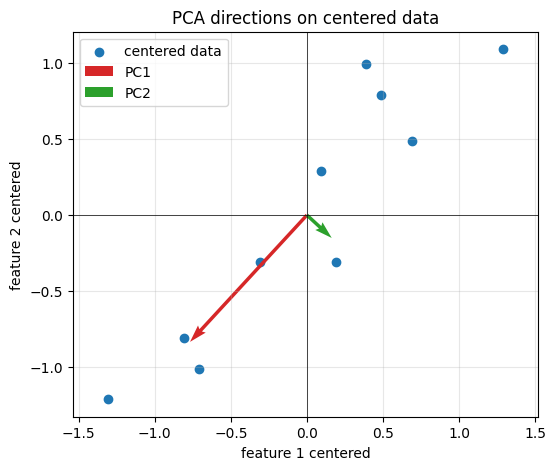

In [39]:
origin = np.zeros(2)
pc1 = Vt_pca[0] * s_pca[0] / np.sqrt(len(X) - 1)
pc2 = Vt_pca[1] * s_pca[1] / np.sqrt(len(X) - 1)

plt.figure(figsize=(6, 5))
plt.scatter(X_centered[:, 0], X_centered[:, 1], color="tab:blue", label="centered data")
plt.quiver(*origin, *pc1, angles="xy", scale_units="xy", scale=1, color="tab:red", label="PC1")
plt.quiver(*origin, *pc2, angles="xy", scale_units="xy", scale=1, color="tab:green", label="PC2")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("feature 1 centered")
plt.ylabel("feature 2 centered")
plt.title("PCA directions on centered data")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.legend()
plt.show()

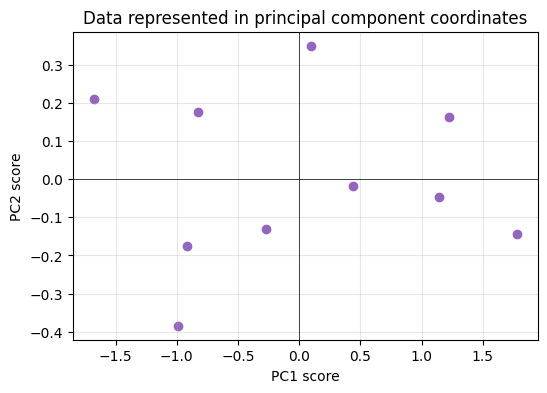

In [40]:
plt.figure(figsize=(6, 4))
plt.scatter(scores[:, 0], scores[:, 1], color="tab:purple")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.title("Data represented in principal component coordinates")
plt.grid(True, alpha=0.3)
plt.show()

The first principal component explains the largest share of variance. Projecting data onto PC1 and PC2 rotates the coordinate system so the strongest variation appears along the first axis.